#### **Creando el grafo del ejercicio 3**

In [142]:
%%file 1.graph
1 6 2 4 3 1
4 4 
4 1 3 3 5 3
5 4
6 4
6 9
-

Overwriting 1.graph


In [143]:

with open('1.graph') as file:
    G = []
    for line in file:
        if line.startswith('-'):
            G.append([])
            continue
        nums = list(map(int, line.split()))
        G.append([(nums[i], nums[i+1]) for i in range(0, len(nums), 2)])

    print(G)

[[(1, 6), (2, 4), (3, 1)], [(4, 4)], [(4, 1), (3, 3), (5, 3)], [(5, 4)], [(6, 4)], [(6, 9)], []]


In [144]:
import graphviz as gv

# Función para visualizar el grafo
def show(G, labels=[], directed=False, weighted=False, path=[], layout='sfdp', rankdir='LR'):
    graph = gv.Digraph('felicidad') if directed else gv.Graph('alegria')
    graph.format = 'svg'
    graph.graph_attr['layout'] = layout
    graph.graph_attr['rankdir'] = rankdir
    graph.edge_attr['color'] = 'gray'
    graph.node_attr['color'] = 'orangered'
    graph.node_attr['width'] = '0.1'
    graph.node_attr['height'] = '0.1'
    graph.node_attr['fontsize'] = '8'
    graph.node_attr['fontcolor'] = 'mediumslateblue'
    graph.node_attr['fontname'] = 'monospace'
    graph.edge_attr['fontsize'] = '8'
    graph.edge_attr['fontname'] = 'monospace'
    n = len(G)
    for i, lbl in enumerate(labels):
        graph.node(str(i), lbl)
    added = set()
    for v, u in enumerate(path):
        if u != -1:
            if weighted:
                w = 0
                for vi, w in G[u]:
                    if vi == v:
                        break
                graph.edge(str(u), str(v), str(w), dir='forward',
                           penwidth='2', color='orange')
            else:
                graph.edge(str(u), str(v), dir='forward',
                           penwidth='2', color='orange')
            added.add(f'{u},{v}')
            added.add(f'{v},{u}')
    for u in range(n):
        for edge in G[u]:
            w = 0
            if weighted:
                v, w = edge
            else:
                v = edge
            draw = False
            if not directed and f'{u},{v}' not in added:
                added.add(f'{u},{v}')
                added.add(f'{v},{u}')
                draw = True
            elif directed and f'{u},{v}' not in added:
                added.add(f'{u},{v}')
                draw = True
            if draw:
                if weighted:
                    graph.edge(str(u), str(v), str(w))
                else:
                    graph.edge(str(u), str(v))
    return graph

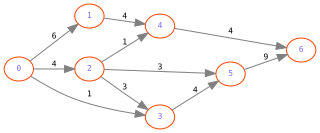

In [145]:
show(G, directed=True, weighted=True, layout='dot', rankdir='LR')

In [146]:
import numpy as np

# Crear matriz de adyacencia
n = len(G)
G1 = np.full((n, n), np.nan)

In [147]:
# Llenar matriz de adyacencia con los pesos de las aristas
for u in range(n):
    for v, w in G[u]:
        G1[u, v] = w
print(G1)
     

[[nan  6.  4.  1. nan nan nan]
 [nan nan nan nan  4. nan nan]
 [nan nan nan  3.  1.  3. nan]
 [nan nan nan nan nan  4. nan]
 [nan nan nan nan nan nan  4.]
 [nan nan nan nan nan nan  9.]
 [nan nan nan nan nan nan nan]]


In [148]:
import math


# Encontrar el camino aumentante
def findAugmentingPath(G, s, t):
    n = len(G)
    visited = [False]*n
    augPath = []

    def dfs(u, bottleNeck):
        visited[u] = True
        augPath.append(u)
        if u == t:
            return bottleNeck
        for v in range(n):
            if G[u, v] > 0 and not visited[v]:
                bn2 = dfs(v, bottleNeck if bottleNeck <= G[u, v] else G[u, v])
                if visited[t]:
                    return bn2
        augPath.pop()

    bottleNeck = dfs(s, math.inf)

    return augPath, bottleNeck


# Algoritmo de Ford-Fulkerson
def fordFulkerson(G, s, t):
    n = len(G)
    Gres = G.copy()
    for i in range(n):
        for j in range(n):
            if not np.isnan(Gres[i, j]) and np.isnan(Gres[j, i]):
                Gres[j, i] = 0
    Gflow = np.zeros((n, n))

    maxFlow = 0
    augmentingPath, bottleNeck = findAugmentingPath(Gres, s, t)
    while augmentingPath:
        for i in range(len(augmentingPath) - 1):
            u = augmentingPath[i]
            v = augmentingPath[i+1]
            Gres[u, v] -= bottleNeck
            Gres[v, u] += bottleNeck
            Gflow[u, v] += bottleNeck
        maxFlow += bottleNeck
        augmentingPath, bottleNeck = findAugmentingPath(Gres, s, t)

    return maxFlow, Gflow

In [149]:
# 1. Cuál será la máxima cantidad de agua que puede recogerse en el almacén F?
maximo_flujo, G2 = fordFulkerson(G1, 0, 6)
print("La maxima cantidad de agua que puede recogerse en el almacen F es: ", maximo_flujo, " Litros")

La maxima cantidad de agua que puede recogerse en el almacen F es:  9.0  Litros


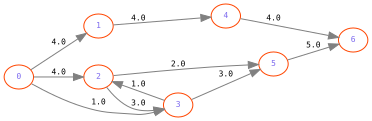

In [150]:
# 2. Determinar que flujo debe circular por cada una de las tuberías para obtener el flujo máximo.
n = len(G2)
G3 = [[] for _ in range(n)]
for i in range(n):
    for j in range(n):
        if G2[i, j] > 0 and G2[i, j] != G2[j, i]:
            G3[i].append((j, G2[i, j]))

show(G3, directed=True, weighted=True, layout='dot', rankdir='LR')
     